In [ ]:
# Calling the Library
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import classification_report

In [ ]:
# Importing the dataset
data = pd.read_csv(r"D:\Visual Studio Code\ML\DataSet\IMDB Dataset.csv")

In [3]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Downloading the Stopwords from NLTK
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DragonBlade\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
#Printing the stopwords in English
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [6]:
#Data Pre-processing 
data = pd.DataFrame(data)
data.shape

(50000, 2)

In [7]:
#Check if the data is missing or not in dataset
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [ ]:
# Removing Unwanted text from the review column and cleaning the text
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data["clean_review"] = data["review"].apply(clean_text)

In [ ]:
# Removing Stopwords from the review column
stop_words = set(stopwords.words("english"))

data["clean_review"] = data["clean_review"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [ ]:
# Applying Lemmatization to the review column
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

data["clean_review"] = data["clean_review"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DragonBlade\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Mapping the sentiment column to numerical values
data["sentiment"] = data["sentiment"].map({
    "positive":1,
    "negative":0
})

In [ ]:
#  Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data["clean_review"],
    data["sentiment"],
    test_size=0.2,
    random_state=42
)

# Using the LSTM Model

In [28]:
#Setting the vocabulary size for the tokenizer
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [ ]:
# Initializing the maximum sequence length for padding
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
# Calculating the maximum and average length of the reviews in the training set
review_lengths = [len(review) for review in X_train_seq]

print("Maximum Length:", max(review_lengths))
print("Average Length:", sum(review_lengths)/len(review_lengths))

Maximum Length: 1416
Average Length: 118.036125


In [ ]:
# Setting the maximum length for padding
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [17]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 200)
(10000, 200)


In [ ]:
# Building the LSTM model
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

model.add(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

c:\Users\DragonBlade\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 115s 224ms/step - accuracy: 0.5133 - loss: 0.6913 - val_accuracy: 0.5404 - val_loss: 0.6744
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 103s 207ms/step - accuracy: 0.5435 - loss: 0.6650 - val_accuracy: 0.5366 - val_loss: 0.6749
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 208ms/step - accuracy: 0.6052 - loss: 0.6177 - val_accuracy: 0.7051 - val_loss: 0.5548
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 106s 213ms/step - accuracy: 0.8484 - loss: 0.3824 - val_accuracy: 0.8666 - val_loss: 0.3369
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 105s 209ms/step - accuracy: 0.9102 - loss: 0.2433 - val_accuracy: 0.8702 - val_loss: 0.3461
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 103s 205ms/step - accuracy: 0.9387 - loss: 0.1804 - val_accuracy: 0.8723 - val_loss: 0.3707
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 204ms/step - accuracy: 0.9567 - loss: 0.1347 - val_accuracy: 0.8680 - val_loss: 0.4132
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 106s 212ms/step - accuracy: 0.9727 -

In [ ]:
# Evaluating the model on the test set
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8625 - loss: 0.8708
Accuracy: 0.862500011920929


In [ ]:
# Predicting the sentiment of the test set
y_pred = model.predict(X_test_pad)

y_pred = (y_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4961
           1       0.85      0.88      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



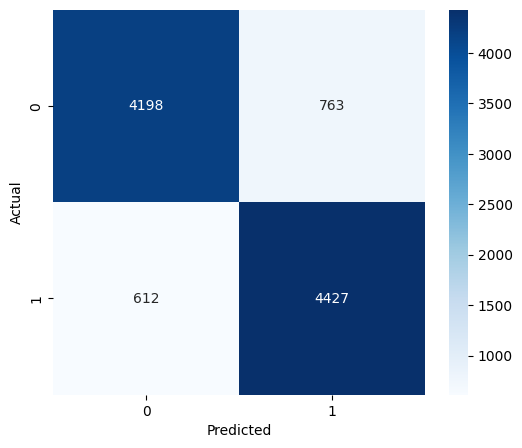

In [ ]:
# Creating a confusion matrix to visualize the performance of the model
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Using the ANN Model


In [ ]:
# Using TF-IDF Vectorization for the reviews
vectorizer = TfidfVectorizer(max_features=5000)

X_train_ann = vectorizer.fit_transform(X_train)

X_test_ann = vectorizer.transform(X_test)

In [ ]:
# Creating the ANN model for sentiment analysis
model_ann =Sequential([
Dense(512),
Dropout(0.5),
Dense(256),
Dense(1)
])

In [ ]:
# Compiling the ANN model
model_ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [35]:
model_ann.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the ANN model    
history = model_ann.fit(
    X_train_ann,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8317 - loss: 0.7713 - val_accuracy: 0.8421 - val_loss: 1.2406
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8554 - loss: 0.6605 - val_accuracy: 0.8621 - val_loss: 0.5376
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8493 - loss: 0.5195 - val_accuracy: 0.8239 - val_loss: 0.5758
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8900 - loss: 0.3910 - val_accuracy: 0.8740 - val_loss: 0.4590
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9036 - loss: 0.3367 - val_accuracy: 0.8706 - val_loss: 0.3948
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9060 - loss: 0.3201 - val_accuracy: 0.8745 - val_loss: 0.4879
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8998 - loss: 0.3430 - val_accuracy: 0.8759 - val_loss: 0.5451
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8869 - loss: 0.3449 - 

In [ ]:
# evaluating the ANN model on the test set
loss, accuracy = model_ann.evaluate(X_test_ann, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8718 - loss: 0.5668
Accuracy: 0.8718000054359436


In [ ]:
# Predicting the sentiment of the test set using the ANN model
y_pred = model_ann.predict(X_test_ann)

y_pred = (y_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4961
           1       0.87      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



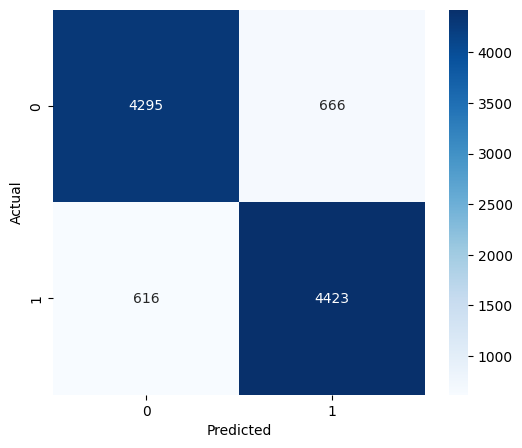

In [ ]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
# Predicting the sentiment of a new review using the LSTM model

def predict_sentiment_LSTM (review):

    # Step 1: Clean the input review
    review = clean_text(review)

    # Step 2: Convert text to sequence
    sequence = tokenizer.texts_to_sequences([review])

    # Step 3: Pad sequence
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # Step 4: Predict
    prediction = model.predict(padded, verbose=0)

    probability = float(prediction[0][0])

    if probability >= 0.5:
        sentiment = "Positive 😊"
    else:
        sentiment = "Negative 😞"

    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Confidence: {probability:.4f}")

    return sentiment, probability

review = """Superhero fatigue has been setting in for quite some time now, with both Marvel and DC struggling to find the right footing. In the race for bigger spectacles, sprawling multiverses, time travel, and interconnected sagas, many superhero films traded genuine emotion and character for sheer scale and experimentation. Audiences, understandably, began to lose interest.
James Gunn rebooted the DC Universe with Superman (2025), introducing the dimpled David Corenswet as the new Man of Steel. While the film dazzled with its scale and visual ambition, it often felt emotionally scattered and underwhelming. What lingered long after the credits, however, were the brief but memorable glimpses of Milly Alcock's carefree, rebellious Supergirl.
Supergirl finally tells Kara Zor-El's story, through an interplanetary adventure and it is refreshingly straightforward. The plot isn't needlessly convoluted. The filmmakers don't attempt to juggle ten different storylines or set up future films at every turn. There is no world-ending threat, no obligatory romance, and no heroine designed to cater to the male gaze. Kara is consumed by something far more profound, the grief of losing her home, her family, and everything she once knew.
Unlike Superman, who arrived on Earth as a baby and was raised in a loving environment, Kara witnessed Krypton's collapse firsthand. She endured the suffering, loss, and destruction. She wasn't granted the luxury of innocence. From that trauma emerges a version of Supergirl who lacks her cousin's boundless optimism and idealism. She is emotionally lost, drifting through life on autopilot, masking her pain with recklessness and a perpetually hungover indifference to the world around her.
The only being she seems to care about is her dog, Krypto. But when a young girl named Ruthye (Eve Ridley) loses her parents in a brutal attack, Kara finds herself reluctantly drawn into another person's grief. The two team up to hunt down Krem (Matthias Schoenaerts), a ruthless human trafficker and leader of the space pirate gang known as the Brigands, who is responsible not only for Ruthye's tragedy but also for harming Krypto. Jason Momoa makes a brief but entertaining appearance as the bounty hunter Lobo.
On the surface, Supergirl is a fairly conventional revenge story. A young girl seeks justice for her murdered family, while a wounded hero pursues the man who hurt her beloved dog. Yet what elevates the film is its bruised but spirited heart and its moving exploration of daughter-parent bond.
Director Craig Gillespie and writer Ana Nogueira craft a brisk, entertaining space adventure that never loses sight of its emotional core. Beneath the action lies a story about grief, loneliness, displacement, and the search for belonging. In many ways, Supergirl succeeds in delivering the emotional resonance that Superman strained to achieve.
The action sequences are thrilling and confidently staged. More importantly, the film never feels like it's pandering. The creators commit fully to their vision of Kara and allow her to exist as a flawed, messy, deeply human character. The result is a superhero film that balances spectacle with a distinctly feminine empathy that gives the story warmth without compromising its edge.
Most importantly, Supergirl feels like her own person. She isn't a reflection of her celebrated cousin’s legacy. She is shaped by her own scars, her own losses, and her own choices. In a world constantly telling women who they should be and how they should look, Kara finds comfort simply in existing on her own terms.
Milly Alcock is superb as an emotionally numb drifter masking deep-seated grief with impulsive behaviour and an almost permanent sense of exhaustion. She channels Kara's dormant rage and lingering heartbreak with remarkable conviction, making her the beating heart of the film. She internalizes the trauma of losing her childhood and being forced to grow up far too quickly. Beneath the unkempt hair, snarky humour and reckless bravado lies a young woman desperately searching for a sense of home, longing for the innocence and softness that life robbed her of too soon. David Corenswet returns as Superman in multiple scenes and is effortlessly charming, his hopeful energy serving as a perfect counterpoint to Kara's emotional turmoil and cynicism. Eve Ridley is sincere as a sidekick. Matthias Schoenaerts brings commanding screen presence, but the character feels thinly sketched and underdeveloped for a central antagonist.
Supergirl is an engaging, heartfelt superhero adventure that may seem generic, even unambitious at first glance, but gradually reveals an emotional depth that stays with you. In a genre increasingly weighed down by spectacle and excess, it stands out by keeping things simple and human."""
predict_sentiment_LSTM(review)

Review: superhero fatigue has been setting in for quite some time now with both marvel and dc struggling to find the right footing in the race for bigger spectacles sprawling multiverses time travel and interconnected sagas many superhero films traded genuine emotion and character for sheer scale and experimentation audiences understandably began to lose interest james gunn rebooted the dc universe with superman introducing the dimpled david corenswet as the new man of steel while the film dazzled with its scale and visual ambition it often felt emotionally scattered and underwhelming what lingered long after the credits however were the brief but memorable glimpses of milly alcock s carefree rebellious supergirl supergirl finally tells kara zor el s story through an interplanetary adventure and it is refreshingly straightforward the plot isn t needlessly convoluted the filmmakers don t attempt to juggle ten different storylines or set up future films at every turn there is no world en

('Negative 😞', 0.04120784252882004)

In [52]:
# Predicting the sentiment of a new review using the ANN model

def predict_sentiment_ANN(review):

    review = clean_text(review)

    review_vector = vectorizer.transform([review])

    prediction = model_ann.predict(review_vector, verbose=0)

    probability = float(prediction[0][0])

    if probability >= 0.5:
        print("Positive 😊")
    else:
        print("Negative 😞")

    print("Confidence:", probability)


review = """Writer-director Prasshant Jha’s romantic comedy is a spiritual sequel to Ginny Weds Sunny. It follows a grumpy middle-class wrestler and handicraft store owner in Rishikesh, whose reputation is ruined when a fake video of him misbehaving with a girl goes viral. As he struggles to find a wife, there’s Ginny, an effervescent, independent Delhi girl who parties hard and agrees to get married after a broken engagement. Unable to find suitable matches, both their families coerce them into hiding their true personalities and professions. But they cannot keep up the facade, and misunderstandings lead them to separate. How this changes Sunny’s perception of city girls, and whether they will reunite, forms the rest of the story.
The film begins on a promising note, making one curious to see how the mismatched couple will find love in each other despite their differences. However, the fragmented story and screenplay toy with one idea after another — first, it’s about how the poles-apart couple will navigate married life. Then the main conflict comes in, and it becomes about the man trying to win his wife over again, his change of heart, the duo falling in love again, and whether they will go through with their divorce. None of these plot points get enough space to breathe, and the narrative turns incohesive. Thoughts feel half-baked and unexplored. How Sunny finds himself and comes out of his small-town biases about women being ‘open-minded’ and independent feels rushed.
The narrative is predictable, and the romance feels cliched. Sunny goes to Delhi and becomes a cab driver to be close to Ginny, and the boy saving the girl from a drunken lout and melting her heart is a dated concept. The movie’s pace is uneven, with only a few scenes holding the viewer’s attention, while the small-town quirks elicit laughter intermittently. A few scenes toward the end feel emotional, but most of them fall flat.
Avinash Tiwary delivers an earnest performance and brings sincerity to Sunny’s vulnerability and confusion. Medha Shankr, as Ginny, is decent in some scenes but struggles to perform consistently. Some characters feel forced, but Sudhir Pandey pulls off his act as Sunny’s father well."""
predict_sentiment_ANN(review)

Negative 😞
Confidence: 0.3886382579803467


In [54]:
# Saving Models
model.save("movie_review_lstm_model.h5")
model_ann.save("movie_review_ann_model.h5")

In [ ]:
# Loading the saved models
model = tensorflow.keras.models.load_model("movie_review_lstm_model.h5")
model_ann = tensorflow.keras.models.load_model("movie_review_ann_model.h5")